# 1. Define the problem

- Target variable -> sales
- That's a regression problem, we need a number as output
- R2 -> success metric

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

In [2]:
sales = pd.read_csv('./sales.csv')

display(sales.head(10))
display(sales.sample(10))
display(sales.tail(10))

display(sales.shape)
display(sales.columns)

,Unnamed: 0,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
0,425390,366,4,2013-04-18,517,1,0,0,0,4422
1,291687,394,6,2015-04-11,694,1,0,0,0,8297
2,411278,807,4,2013-08-29,970,1,1,0,0,9729
3,664714,802,2,2013-05-28,473,1,1,0,0,6513
4,540835,726,4,2013-10-10,1068,1,1,0,0,10882
5,687329,674,2,2013-03-19,1016,1,1,0,0,8406
6,600327,659,7,2014-06-08,0,0,0,0,0,0
7,96265,27,3,2014-07-16,1106,1,1,0,1,11162
8,364435,347,6,2013-05-11,448,1,0,0,0,5559
9,163146,288,2,2013-06-25,291,1,0,0,0,3997


,Unnamed: 0,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
295626,552176,533,4,2014-10-02,1163,1,1,0,0,11394
445831,335493,550,3,2015-02-18,525,1,1,0,0,6833
225336,560397,407,1,2013-02-18,419,1,1,0,0,5681
69031,66879,463,3,2015-07-29,758,1,1,0,1,5274
468901,133157,579,1,2014-09-08,814,1,0,0,0,7278
525435,430299,618,1,2013-12-30,658,1,0,0,1,8678
176193,548318,1005,3,2014-09-24,811,1,0,0,0,4867
383588,450742,619,5,2015-04-24,394,1,0,0,0,3635
310566,700067,619,3,2013-07-17,483,1,1,0,0,5002
627110,522862,581,4,2014-01-23,629,1,1,0,0,6165


,Unnamed: 0,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
640830,374564,955,4,2013-04-11,386,1,1,0,0,3745
640831,448242,341,3,2014-06-11,744,1,0,0,0,5451
640832,610581,359,4,2015-05-07,615,1,1,0,0,6881
640833,122579,77,6,2015-01-17,701,1,0,0,0,8219
640834,304137,329,7,2013-09-15,0,0,0,0,0,0
640835,359783,409,6,2013-10-26,483,1,0,0,0,4553
640836,152315,97,1,2014-04-14,987,1,1,0,0,12307
640837,117952,987,1,2014-07-07,925,1,0,0,0,6800
640838,435829,1084,4,2014-06-12,725,1,0,0,0,5344
640839,305711,695,7,2015-05-03,0,0,0,0,0,0


(640840, 10)

Index(['Unnamed: 0', 'store_ID', 'day_of_week', 'date', 'nb_customers_on_day',
       'open', 'promotion', 'state_holiday', 'school_holiday', 'sales'],
      dtype='str')

In [3]:
display(sales.dtypes)
display(sales['state_holiday'].unique())

Unnamed: 0             int64
store_ID               int64
day_of_week            int64
date                     str
nb_customers_on_day    int64
open                   int64
promotion              int64
state_holiday            str
school_holiday         int64
sales                  int64
dtype: object

<ArrowStringArray>
['0', 'a', 'c', 'b']
Length: 4, dtype: str

In [4]:
display(sales.info())

<class 'pandas.DataFrame'>
RangeIndex: 640840 entries, 0 to 640839
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   Unnamed: 0           640840 non-null  int64
 1   store_ID             640840 non-null  int64
 2   day_of_week          640840 non-null  int64
 3   date                 640840 non-null  str  
 4   nb_customers_on_day  640840 non-null  int64
 5   open                 640840 non-null  int64
 6   promotion            640840 non-null  int64
 7   state_holiday        640840 non-null  str  
 8   school_holiday       640840 non-null  int64
 9   sales                640840 non-null  int64
dtypes: int64(8), str(2)
memory usage: 55.6 MB


None

In [5]:
display(sales.describe())

,Unnamed: 0,store_ID,day_of_week,nb_customers_on_day,open,promotion,school_holiday,sales
count,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000
mean,355990.675084,558.211348,4.000189,633.398577,0.830185,0.381718,0.178472,5777.469011
std,205536.290268,321.878521,1.996478,464.094416,0.375470,0.485808,0.382910,3851.338083
min,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,178075.750000,280.000000,2.000000,405.000000,1.000000,0.000000,0.000000,3731.000000
50%,355948.500000,558.000000,4.000000,609.000000,1.000000,0.000000,0.000000,5746.000000
75%,533959.250000,837.000000,6.000000,838.000000,1.000000,1.000000,0.000000,7860.000000
max,712044.000000,1115.000000,7.000000,5458.000000,1.000000,1.000000,1.000000,41551.000000


In [6]:
print(sales.isna().sum())

Unnamed: 0             0
store_ID               0
day_of_week            0
date                   0
nb_customers_on_day    0
open                   0
promotion              0
state_holiday          0
school_holiday         0
sales                  0
dtype: int64


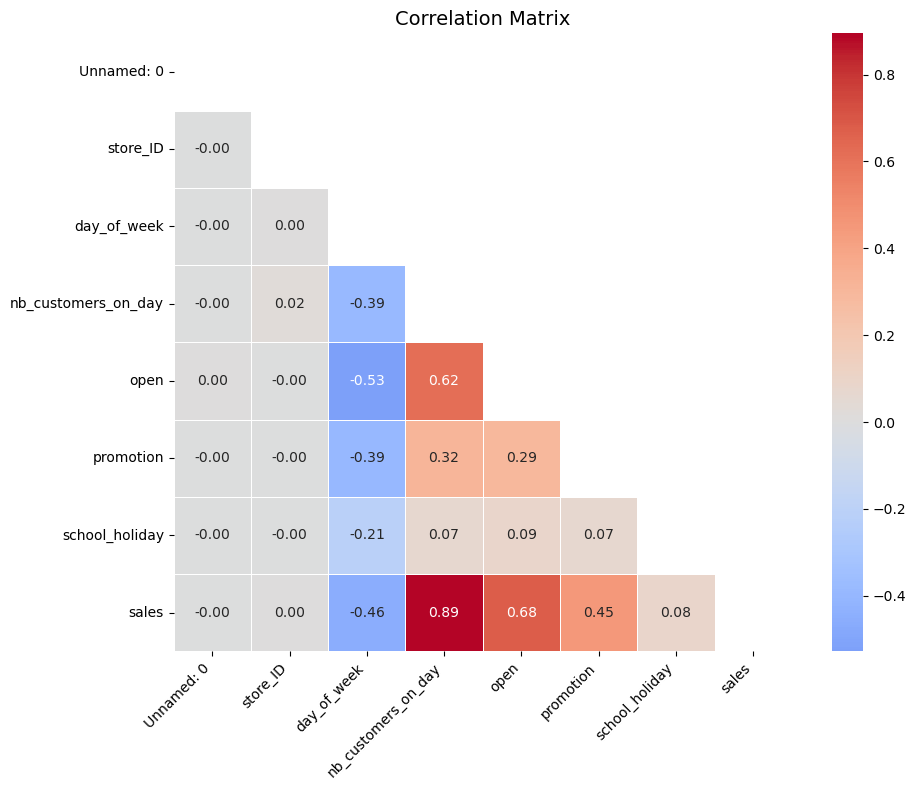


Top 3 Positive Correlations:
nb_customers_on_day  sales    0.894872
open                 sales    0.678463
nb_customers_on_day  open     0.617264
dtype: float64

Top 3 Negative Correlations:
sales  promotion        NaN
       school_holiday   NaN
       sales            NaN
dtype: float64


In [7]:
def show_corr(df):
    """Display triangular correlation matrix"""
    # Create correlation matrix
    corr = df.corr()
    
    # Create mask for upper triangle
    mask = np.triu(np.ones_like(corr, dtype=bool))
    
    # Plot
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, 
                mask=mask, 
                annot=True, 
                cmap='coolwarm', 
                center=0, 
                fmt='.2f',
                square=True,
                linewidths=0.5)
    plt.title('Correlation Matrix', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    
    # Print top correlations
    corr_pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    corr_pairs = corr_pairs.stack().sort_values(ascending=False)
    
    print("\nTop 3 Positive Correlations:")
    print(corr_pairs.head(3))
    
    print("\nTop 3 Negative Correlations:")
    print(corr_pairs.tail(3))


show_corr(sales.drop(['date', 'state_holiday'], axis=1))

In [8]:
store_closed_records = sales[sales['open'] == 0]['sales']
display(store_closed_records.value_counts())

nb_customers_on_day_closed_records = sales[sales['open'] == 0]['nb_customers_on_day']
display(nb_customers_on_day_closed_records.value_counts())

sales
0    108824
Name: count, dtype: int64

nb_customers_on_day
0    108824
Name: count, dtype: int64

<Figure size 5500x2500 with 0 Axes>

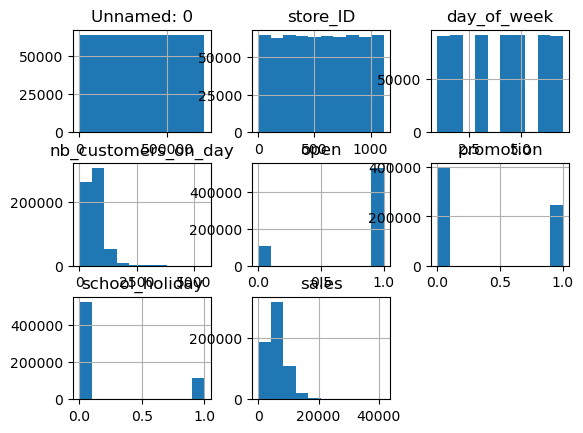

In [9]:
fig = plt.figure(figsize=(55, 25))
sales.hist()
plt.show()

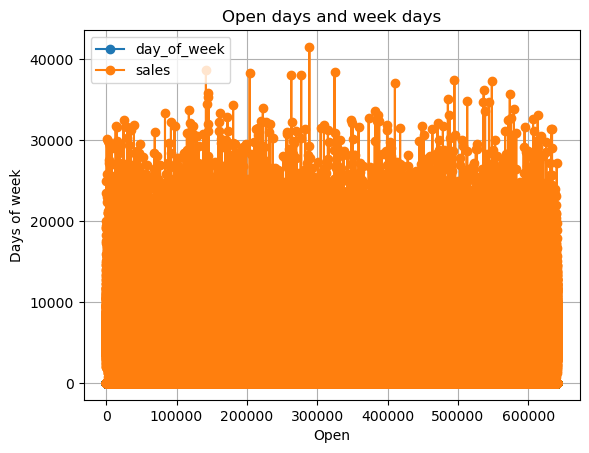

In [10]:
# Unnamed, store_ID, date
sales[['day_of_week', 'sales']].plot(kind='line', marker='o')

plt.title('Open days and week days')
plt.xlabel('Open')
plt.ylabel('Days of week')
plt.grid(True)
plt.show()

In [11]:

from sklearn.model_selection import train_test_split

def split_data(sales_data):
    X = sales_data.drop('sales', axis=1)
    y = sales_data['sales']

    
    # 70% train, 15% val, 15% test
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
    
    return X_train, X_val, X_test, y_train, y_val, y_test

display(sales.head(10))
display(sales.shape)

X_train, X_val, X_test, y_train, y_val, y_test = split_data(sales)

display(X_train.head(10))
display(X_train.shape)


,Unnamed: 0,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
0,425390,366,4,2013-04-18,517,1,0,0,0,4422
1,291687,394,6,2015-04-11,694,1,0,0,0,8297
2,411278,807,4,2013-08-29,970,1,1,0,0,9729
3,664714,802,2,2013-05-28,473,1,1,0,0,6513
4,540835,726,4,2013-10-10,1068,1,1,0,0,10882
5,687329,674,2,2013-03-19,1016,1,1,0,0,8406
6,600327,659,7,2014-06-08,0,0,0,0,0,0
7,96265,27,3,2014-07-16,1106,1,1,0,1,11162
8,364435,347,6,2013-05-11,448,1,0,0,0,5559
9,163146,288,2,2013-06-25,291,1,0,0,0,3997


(640840, 10)

,Unnamed: 0,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday
439297,228265,741,2,2013-02-26,658,1,0,0,0
326963,435586,886,6,2013-11-02,533,1,0,0,0
348005,263009,18,4,2013-06-13,650,1,0,0,0
270031,328240,641,1,2013-11-18,754,1,1,0,0
106547,301475,36,6,2015-03-21,1065,1,0,0,0
94066,231727,978,2,2013-03-12,770,1,0,0,0
184808,499159,287,3,2013-01-09,839,1,1,0,0
88066,654691,592,1,2014-06-30,713,1,1,0,0
565280,361918,738,2,2013-04-30,813,1,1,0,0
405521,237478,284,2,2013-09-03,317,1,0,0,1


(448588, 9)

In [12]:

display(sales.columns)

X_train_clean = X_train.copy()
X_val_clean = X_val.copy()
X_test_clean = X_test.copy()

for dataset in [X_train_clean, X_val_clean, X_test_clean]:
 dataset.drop(columns=['Unnamed: 0', 'store_ID', 'date'], inplace=True)
 display(dataset)
 
X_train_clean = pd.get_dummies(X_train_clean, columns=['state_holiday'], drop_first=True, dtype=int)
X_val_clean = pd.get_dummies(X_val_clean, columns=['state_holiday'], drop_first=True, dtype=int)
X_test_clean = pd.get_dummies(X_test_clean, columns=['state_holiday'], drop_first=True, dtype=int)
display(X_train_clean)

Index(['Unnamed: 0', 'store_ID', 'day_of_week', 'date', 'nb_customers_on_day',
       'open', 'promotion', 'state_holiday', 'school_holiday', 'sales'],
      dtype='str')

,day_of_week,nb_customers_on_day,open,promotion,state_holiday,school_holiday
439297,2,658,1,0,0,0
326963,6,533,1,0,0,0
348005,4,650,1,0,0,0
270031,1,754,1,1,0,0
106547,6,1065,1,0,0,0
...,...,...,...,...,...,...
110268,4,1040,1,0,0,1
259178,1,714,1,1,0,0
365838,4,0,0,0,a,1
131932,5,0,0,1,b,1


,day_of_week,nb_customers_on_day,open,promotion,state_holiday,school_holiday
85484,1,584,1,0,0,0
554197,7,0,0,0,0,0
283491,4,586,1,0,0,0
203367,7,0,0,0,0,0
116111,3,469,1,0,0,0
...,...,...,...,...,...,...
546779,3,1623,1,1,0,0
565944,2,835,1,1,0,0
265136,3,524,1,0,0,1
303253,3,521,1,1,0,1


,day_of_week,nb_customers_on_day,open,promotion,state_holiday,school_holiday
586068,4,0,0,0,a,0
450188,5,1356,1,1,0,0
444261,4,991,1,0,0,0
25114,4,442,1,1,0,0
306712,5,743,1,0,0,1
...,...,...,...,...,...,...
622988,1,692,1,1,0,0
291237,4,899,1,1,0,0
213174,7,2056,1,0,0,0
291740,6,692,1,0,0,0


,day_of_week,nb_customers_on_day,open,promotion,school_holiday,state_holiday_a,state_holiday_b,state_holiday_c
439297,2,658,1,0,0,0,0,0
326963,6,533,1,0,0,0,0,0
348005,4,650,1,0,0,0,0,0
270031,1,754,1,1,0,0,0,0
106547,6,1065,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...
110268,4,1040,1,0,1,0,0,0
259178,1,714,1,1,0,0,0,0
365838,4,0,0,0,1,1,0,0
131932,5,0,0,1,1,0,1,0


In [13]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, r2_score

baseline = DummyRegressor(strategy='mean')
baseline.fit(X_train_clean, y_train)
y_pred_baseline = baseline.predict(X_test_clean)

print("Baseline (Dummy) Performance:")
print(f"MAE: {mean_absolute_error(y_test, y_pred_baseline):.2f}")
print(f"R²: {r2_score(y_test, y_pred_baseline):.4f}")

Baseline (Dummy) Performance:
MAE: 2887.89
R²: -0.0000


In [19]:
# Decision Tree Model
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import plot_tree

# Train
dt_model = DecisionTreeRegressor(random_state=42, max_depth=10, min_samples_split=10)
dt_model.fit(X_train_clean, y_train)

# Predict
y_pred_val = dt_model.predict(X_val_clean)
y_pred_test = dt_model.predict(X_test_clean)

# Evaluate validation
print("Decision Tree - Validation Performance:")
print(f"MAE: {mean_absolute_error(y_val, y_pred_val):.2f}")
print(f"MSE: {mean_squared_error(y_val, y_pred_val):.2f}")
print(f"R²: {r2_score(y_val, y_pred_val):.4f}")

# Evaluate test
print("\nDecision Tree - Test Performance:")
print(f"MAE: {mean_absolute_error(y_test, y_pred_test):.2f}")
print(f"MSE: {mean_squared_error(y_test, y_pred_test):.2f}")
print(f"R²: {r2_score(y_test, y_pred_test):.4f}")



Decision Tree - Validation Performance:
MAE: 897.08
MSE: 1869691.82
R²: 0.8740

Decision Tree - Test Performance:
MAE: 897.20
MSE: 1885573.21
R²: 0.8723


In [ ]:
#compare models
models = {
    'Baseline': DummyRegressor(strategy='mean'),
    'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=10),
    # Add your models here
}

results = []
for name, model in models.items():
    model.fit(X_train_clean, y_train)
    y_pred = model.predict(X_test_clean)
    results.append({
        'Model': name,
        'MAE': mean_absolute_error(y_test, y_pred),
        'R²': r2_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
print(results_df.sort_values('R²', ascending=False))

           Model          MAE        R²
1  Decision Tree   897.250085  0.872325
0       Baseline  2887.888068 -0.000010
